In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [6]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [9]:
x=df.drop(columns=['Survived'])
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [10]:
x_train

,Age,Fare
140,NaN,15.2458
439,31.0,10.5000
817,31.0,37.0042
378,20.0,4.0125
491,21.0,7.2500
...,...,...
835,39.0,83.1583
192,19.0,7.8542
629,NaN,7.7333
559,36.0,17.4000


In [11]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']

In [12]:
x_train

,Age,Fare,Age_imputed
140,NaN,15.2458,NaN
439,31.0,10.5000,31.0
817,31.0,37.0042,31.0
378,20.0,4.0125,20.0
491,21.0,7.2500,21.0
...,...,...,...
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,NaN
559,36.0,17.4000,36.0


In [13]:
x_test.tail()

,Age,Fare,Age_imputed
780,13.0,7.2292,13.0
837,NaN,8.0500,NaN
215,31.0,113.2750,31.0
833,23.0,7.8542,23.0
372,19.0,8.0500,19.0


In [25]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_train['Age_imputed'].isnull().sum(), random_state=42, replace=True)
    .values
)

x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_test['Age_imputed'].isnull().sum(), random_state=42, replace=True)
    .values
)

In [21]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([28.  , 22.  , 29.  , 28.  , 43.  , 46.  , 48.  , 14.  , 24.  ,
       28.  , 29.  , 40.5 , 38.  , 16.  , 50.  , 24.  , 24.  , 27.  ,
       44.  , 27.  , 18.  , 65.  , 49.  , 20.  ,  2.  , 18.  , 70.5 ,
       34.  , 61.  ,  3.  , 20.  , 17.  , 23.  , 16.  , 39.  , 38.  ,
        0.83, 31.  , 28.  , 17.  , 28.  , 23.  , 32.  , 35.  , 30.5 ,
       31.  , 35.  , 24.  , 74.  , 32.  , 38.  , 17.  , 24.  ,  2.  ,
       59.  , 30.  , 17.  , 22.  , 16.  ,  9.  ,  3.  , 47.  , 34.  ,
       21.  , 24.  , 19.  , 18.  , 25.  , 26.  , 24.  , 20.  , 56.  ,
       45.5 , 24.  , 22.  , 41.  , 42.  , 44.  , 21.  , 33.  , 18.  ,
       24.  , 35.  , 11.  , 30.5 , 23.  , 36.  , 24.  , 39.  , 27.  ,
       24.  , 19.  , 30.  ,  4.  , 50.  , 20.  , 24.  , 36.  , 22.  ,
       18.  , 26.  , 41.  , 33.  , 16.  , 28.  , 22.  , 28.  , 35.  ,
       21.  , 31.  , 21.  , 37.  , 30.  , 23.  ,  8.  , 19.  , 61.  ,
       32.  , 24.  , 49.  ,  2.  , 40.5 , 26.  , 36.  , 33.  , 42.  ,
       31.  , 21.  ,

In [26]:
x_train

,Age,Fare,Age_imputed
140,NaN,15.2458,2.0
439,31.0,10.5000,31.0
817,31.0,37.0042,31.0
378,20.0,4.0125,20.0
491,21.0,7.2500,21.0
...,...,...,...
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,18.0
559,36.0,17.4000,36.0


In [27]:
x_train.isnull().sum()

Age            141
Fare             0
Age_imputed      0
dtype: int64

C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_21812\3412159478.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='Original',hist=False)
C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_21812\3412159478.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

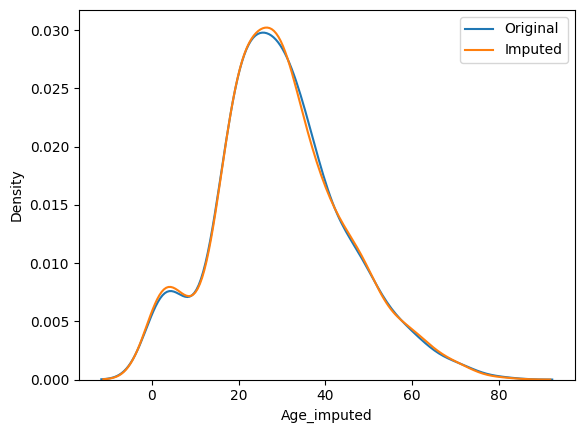

In [28]:
sns.distplot(x_train['Age'],label='Original',hist=False)
sns.distplot(x_train['Age_imputed'],label='Imputed',hist=False)

plt.legend()
plt.show()

In [29]:
print("Original Variable Variance",x_train['Age'].var())
print("Imputed Variable Variance",x_train['Age_imputed'].var())

Original Variable Variance 213.7165085187575
Imputed Variable Variance 216.30243113493415


In [30]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2513.549265,79.072379,66.501738
Age,79.072379,213.716509,213.716509
Age_imputed,66.501738,213.716509,216.302431


<Axes: >

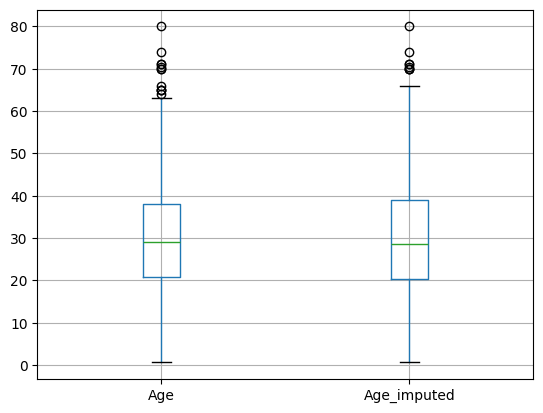

In [31]:
x_train[['Age','Age_imputed']].boxplot()

### Catogerical Data

In [34]:
data=pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [35]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [36]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [40]:
x=data
y=data['SalePrice']

In [41]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [42]:
x_train

,FireplaceQu,GarageQual,SalePrice
618,Gd,TA,314813
870,NaN,TA,109500
92,NaN,TA,163500
817,Gd,TA,271000
302,TA,TA,205000
...,...,...,...
763,Gd,TA,337000
835,NaN,TA,128000
1216,NaN,TA,112000
559,TA,TA,234000


In [43]:
x_train['GarageQual_imputed']=x_train['GarageQual']
x_test['GarageQual_imputed']=x_test['GarageQual']

In [46]:
x_train['FireplaceQu_imputed']=x_train['FireplaceQu']
x_test['FireplaceQu_imputed']=x_test['FireplaceQu']

In [51]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
504,Fa,TA,147000,TA,Fa
292,Gd,TA,131000,TA,Gd
70,Gd,TA,244000,TA,Gd
506,TA,TA,215000,TA,TA
318,TA,TA,260000,TA,TA


In [52]:
## Imputed GarageQual Traing data
x_train.loc[x_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    x_train['GarageQual']
    .dropna()
    .sample(x_train['GarageQual_imputed'].isnull().sum(),
            random_state=42,
            replace=True)
    .values
)

## Imputed GarageQual test data 
x_test.loc[x_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    x_train['FireplaceQu']
    .dropna()
    .sample(x_test['FireplaceQu_imputed'].isnull().sum(),
            random_state=42,
            replace=True)
    .values
)

In [54]:
temp = pd.concat(
        [
            x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
            x_train['GarageQual_imputed'].value_counts() / len(x_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [55]:
temp

,original,imputed
TA,0.950450,0.951199
Fa,0.036036,0.035959
Gd,0.009009,0.008562
Po,0.002703,0.002568
Ex,0.001802,0.001712


In [56]:
temp = pd.concat(
        [
            x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
            x_train['FireplaceQu_imputed'].value_counts() / len(x_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [57]:
temp

,original,imputed
Gd,0.478120,0.252568
TA,0.416532,0.220034
Fa,0.047002,0.024829
Ex,0.030794,0.016267
Po,0.027553,0.014555


C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_21812\2578983325.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_21812\2578983325.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom

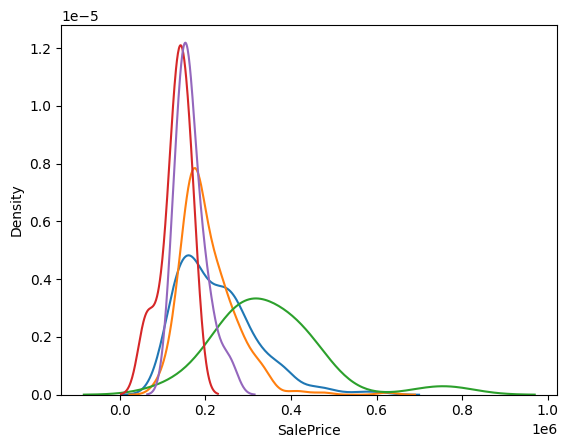

In [59]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_21812\484091634.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_21812\484091634.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/m

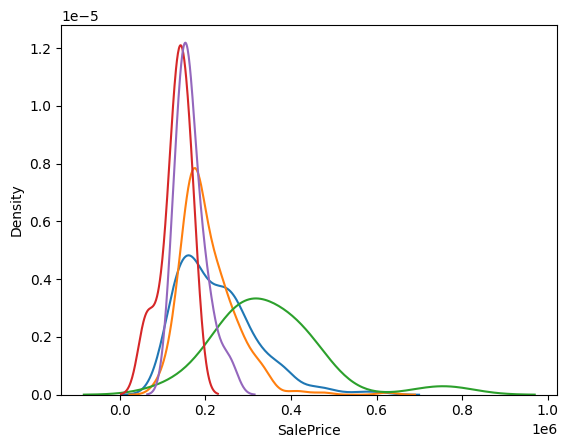

In [60]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()